# Лабораторная работа 4: Кластеризация

## 3 вариант: E-commerce Fraud Dataset

**Цель работы:** Изучение алгоритмов и методов кластеризации на практике с использованием датасета о мошеннических транзакциях в электронной коммерции.

## Часть 1: Создание и анализ синтетического датасета

### Импорт необходимых библиотек

Импортируем все необходимые библиотеки для работы с данными, машинным обучением и визуализацией.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_mutual_info_score, adjusted_rand_score
from sklearn.metrics import fowlkes_mallows_score, homogeneity_score, completeness_score, v_measure_score
from sklearn.metrics.cluster import contingency_matrix

from scipy.cluster.hierarchy import dendrogram, linkage
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

np.random.seed(0)

### Функция для создания синтетического датасета

Создаём функцию, которая генерирует датасет с тремя группами точек с разными параметрами распределения.

In [4]:
def make_data(n, seed):
    np.random.seed(seed)
    shift_matrix = np.array(
        [
            [3, 3],
            [6, 9],
            [9, 3]
        ]
    )
    data = np.random.randn(3, 2, n) + shift_matrix.reshape((3, 2, 1))
    data = np.swapaxes(data, 1, 2)
    data = data.reshape((-1, 2))
    df = pd.DataFrame(
        {
            'x': data[:, 0],
            'y': data[:, 1]
        },
        columns=['x', 'y']
    )
    df = df.sample(frac=1.0)
    return df

### Создание датасета Часть 1

Применяем функцию для создания синтетического датасета. Выбираем параметр n от 30 до 100.

In [5]:
n = 50
df_part1 = make_data(n, seed=0)
print(f"Размер датасета Части 1: {df_part1.shape}")
print(f"\nПервые 20 строк:")
display(df_part1.head(20))
print(f"\nОписательная статистика:")
display(df_part1.describe())

Размер датасета Части 1: (150, 2)

Первые 20 строк:


,x,y
19,2.145904,3.051945
103,9.655264,2.680672
14,3.443863,3.177426
117,9.379152,3.088422
60,7.867559,8.501968
94,8.383145,9.523277
13,3.121675,1.273717
133,9.416050,4.536377
147,10.079619,3.582954
11,4.454274,2.640447



Описательная статистика:


,x,y
count,150.000000,150.000000
mean,6.090785,4.964274
std,2.562900,2.961568
min,0.447010,0.227407
25%,3.957251,2.650503
50%,6.386216,3.553422
75%,8.397799,8.130117
max,11.259309,11.163236


### **Стандартизация данных**
Выполняем стандартизацию случайных данных для корректного отображения:

In [6]:
scaler = StandardScaler()
df_part1_scaled = scaler.fit_transform(df_part1)

print(f"Среднее значение после стандартизации: {df_part1_scaled.mean(axis=0)[:2]}")
print(f"Стандартное отклонение после стандартизации: {df_part1_scaled.std(axis=0)[:2]}")
print(f"\nДанные готовы к кластеризации")

Среднее значение после стандартизации: [-5.92118946e-18 -2.96059473e-16]
Стандартное отклонение после стандартизации: [1. 1.]

Данные готовы к кластеризации


### K-means кластеризация для 3 кластеров

Применяем алгоритм K-means с количеством кластеров, равным 3. Это должно соответствовать трём группам в синтетическом датасете.

In [7]:
kmeans_3 = KMeans(n_clusters=3, random_state=0)
labels_3 = kmeans_3.fit_predict(df_part1_scaled)

display(labels_3)
print(f"Количество кластеров: {len(np.unique(labels_3))}")
print(f"Уникальные метки кластеров: {np.unique(labels_3)}")
print(f"Количество объектов в каждом кластере: {np.bincount(labels_3)}")
print(f"\nЦентры кластеров (в стандартизованном пространстве):")
print(kmeans_3.cluster_centers_)

array([1, 0, 1, 0, 2, 2, 1, 0, 0, 1, 2, 0, 0, 0, 1, 1, 1, 1, 2, 1, 1, 2,
       0, 0, 2, 0, 1, 2, 0, 0, 1, 0, 1, 2, 1, 0, 0, 0, 1, 2, 0, 0, 2, 1,
       2, 1, 2, 1, 1, 2, 0, 1, 2, 0, 1, 2, 2, 2, 0, 1, 0, 2, 2, 1, 1, 2,
       1, 1, 1, 0, 2, 1, 2, 1, 1, 2, 0, 1, 2, 2, 1, 1, 2, 0, 2, 2, 0, 2,
       1, 2, 1, 2, 1, 0, 0, 2, 2, 2, 2, 0, 2, 2, 0, 0, 1, 1, 1, 0, 1, 2,
       0, 1, 0, 1, 1, 0, 0, 1, 2, 1, 1, 2, 2, 0, 2, 0, 2, 0, 0, 0, 2, 0,
       0, 1, 2, 0, 1, 1, 2, 2, 0, 0, 0, 0, 2, 2, 1, 0, 2, 0], dtype=int32)

Количество кластеров: 3
Уникальные метки кластеров: [0 1 2]
Количество объектов в каждом кластере: [50 50 50]

Центры кластеров (в стандартизованном пространстве):
[[ 1.09009516 -0.66335116]
 [-1.15498451 -0.67257208]
 [ 0.06488935  1.33592323]]


### Визуализация кластеров для K=3

Визуализируем результаты кластеризации на скаттер-графике, выделяя кластеры разными цветами и отмечая центры.

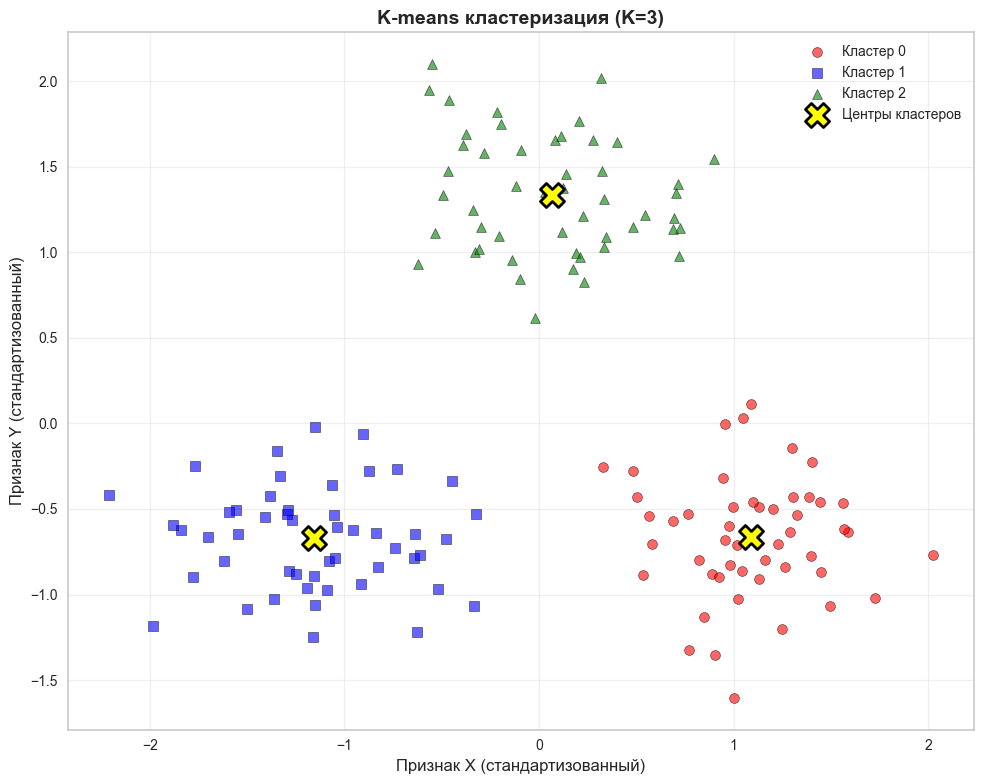

График визуализирует три кластера разными цветами.
Жёлтые кресты показывают центроиды кластеров.


In [8]:
plt.figure(figsize=(10, 8))
colors = ['red', 'blue', 'green']
markers = ['o', 's', '^']
for i in range(3):
    cluster_points = df_part1_scaled[labels_3 == i]
    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        c=colors[i],
        label=f'Кластер {i}',
        s=50,
        marker=markers[i],
        alpha=0.6,
        edgecolors='black',
        linewidth=0.5
    )

plt.scatter(
    kmeans_3.cluster_centers_[:, 0],
    kmeans_3.cluster_centers_[:, 1],
    c='yellow',
    s=300,
    marker='X',
    edgecolors='black',
    linewidth=2,
    label='Центры кластеров'
)

plt.title('K-means кластеризация (K=3)', fontsize=14, fontweight='bold')
plt.xlabel('Признак X (стандартизованный)', fontsize=12)
plt.ylabel('Признак Y (стандартизованный)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("График визуализирует три кластера разными цветами.")
print("Жёлтые кресты показывают центроиды кластеров.")

### Коэффициент силуэта для K=3

Вычисляем коэффициент силуэта, который показывает качество кластеризации. Значения близкие к 1 указывают на хорошо разделённые кластеры.

In [9]:
silhouette_3 = silhouette_score(df_part1_scaled, labels_3)

print(f"Коэффициент силуэта для K=3: {silhouette_3:.4f}")
print(f"\nИнтерпретация:")
print(f"  - Значение близко к 1: кластеры хорошо разделены")
print(f"  - Значение близко к 0: кластеры перекрываются")
print(f"  - Значение отрицательное: объекты неправильно назначены кластерам")

Коэффициент силуэта для K=3: 0.6904

Интерпретация:
  - Значение близко к 1: кластеры хорошо разделены
  - Значение близко к 0: кластеры перекрываются
  - Значение отрицательное: объекты неправильно назначены кластерам


### K-means кластеризация для K=2

In [10]:
kmeans_2 = KMeans(n_clusters=2, random_state=0)
labels_2 = kmeans_2.fit_predict(df_part1_scaled)
silhouette_2 = silhouette_score(df_part1_scaled, labels_2)

print(f"Результаты для K=2:")
print(f"Количество объектов в каждом кластере: {np.bincount(labels_2)}")
print(f"Коэффициент силуэта: {silhouette_2:.4f}")

Результаты для K=2:
Количество объектов в каждом кластере: [ 50 100]
Коэффициент силуэта: 0.4809


### Визуализация кластеров для K=2

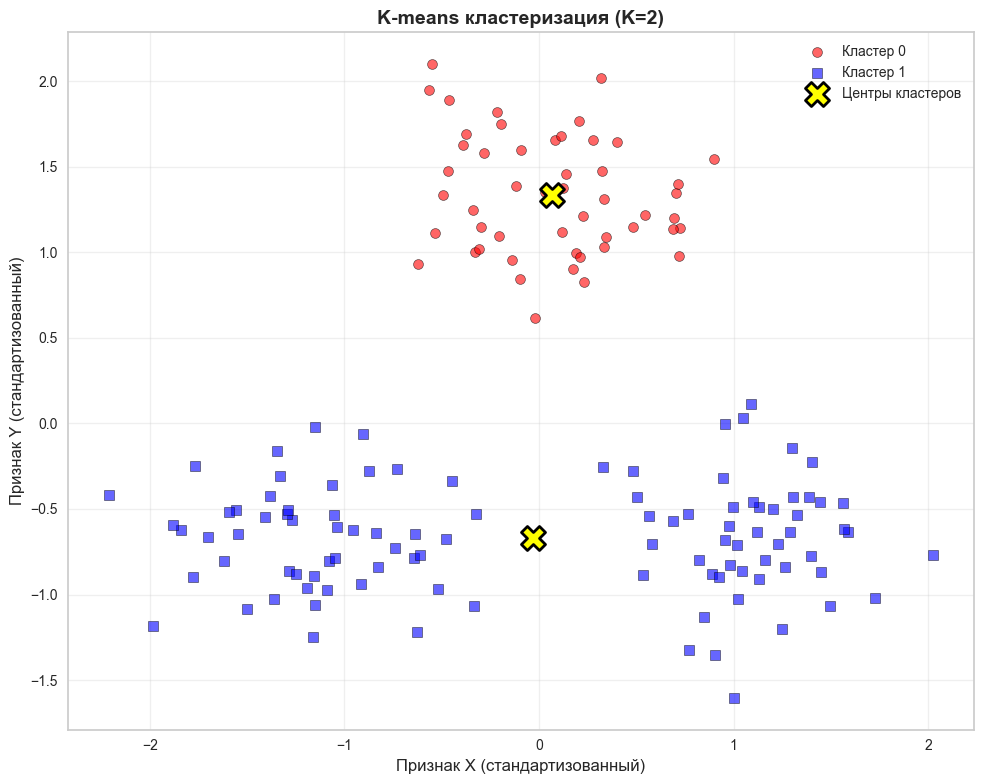

In [11]:
plt.figure(figsize=(10, 8))
colors_2 = ['red', 'blue']
markers_2 = ['o', 's']
for i in range(2):
    cluster_points = df_part1_scaled[labels_2 == i]
    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        c=colors_2[i],
        label=f'Кластер {i}',
        s=50,
        marker=markers_2[i],
        alpha=0.6,
        edgecolors='black',
        linewidth=0.5
    )
    
plt.scatter(
    kmeans_2.cluster_centers_[:, 0],
    kmeans_2.cluster_centers_[:, 1],
    c='yellow',
    s=300,
    marker='X',
    edgecolors='black',
    linewidth=2,
    label='Центры кластеров'
)

plt.title('K-means кластеризация (K=2)', fontsize=14, fontweight='bold')
plt.xlabel('Признак X (стандартизованный)', fontsize=12)
plt.ylabel('Признак Y (стандартизованный)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### K-means кластеризация для K=4

In [12]:
kmeans_4 = KMeans(n_clusters=4, random_state=0)
labels_4 = kmeans_4.fit_predict(df_part1_scaled)
silhouette_4 = silhouette_score(df_part1_scaled, labels_4)

print(f"Результаты для K=4:")
print(f"Количество объектов в каждом кластере: {np.bincount(labels_4)}")
print(f"Коэффициент силуэта: {silhouette_4:.4f}")

Результаты для K=4:
Количество объектов в каждом кластере: [22 50 28 50]
Коэффициент силуэта: 0.5721


### Визуализация кластеров для K=4

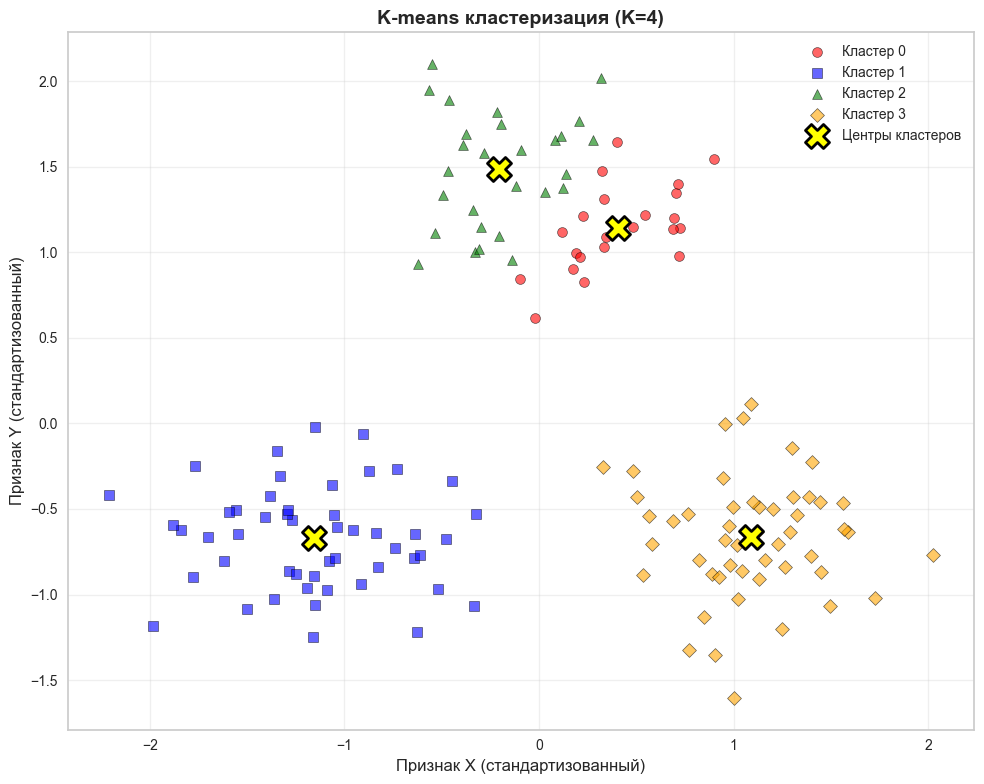

In [13]:
plt.figure(figsize=(10, 8))
colors_4 = ['red', 'blue', 'green', 'orange']
markers_4 = ['o', 's', '^', 'D']

for i in range(4):
    cluster_points = df_part1_scaled[labels_4 == i]
    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        c=colors_4[i],
        label=f'Кластер {i}',
        s=50,
        marker=markers_4[i],
        alpha=0.6,
        edgecolors='black',
        linewidth=0.5
    )

plt.scatter(
    kmeans_4.cluster_centers_[:, 0],
    kmeans_4.cluster_centers_[:, 1],
    c='yellow',
    s=300,
    marker='X',
    edgecolors='black',
    linewidth=2,
    label='Центры кластеров'
)

plt.title('K-means кластеризация (K=4)', fontsize=14, fontweight='bold')
plt.xlabel('Признак X (стандартизованный)', fontsize=12)
plt.ylabel('Признак Y (стандартизованный)', fontsize=12)
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Сравнение результатов для K=2, K=3, K=4

In [14]:
print("-"*60)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ ДЛЯ РАЗНЫХ КОЛИЧЕСТВ КЛАСТЕРОВ")
print("-"*60)

comparison_results = pd.DataFrame(
    {
        'K кластеров': [2, 3, 4],
        'Коэффициент силуэта': [silhouette_2, silhouette_3, silhouette_4],
        'Инертия (сумма квадратов)': [kmeans_2.inertia_, kmeans_3.inertia_, kmeans_4.inertia_],
        'Число итераций': [kmeans_2.n_iter_, kmeans_3.n_iter_, kmeans_4.n_iter_]
    }
)

print("\n" + comparison_results.to_string(index=False))

print("\n" + "-"*60)
print("ВЫВОДЫ:")
print("-"*60)
print("1. K=3 даёт наивысший коэффициент силуэта, что соответствует трём группам в исходных данных.")
print("2. К увеличению K от 2 к 3 приводит к улучшению качества.")
print("3. При K=4 качество немного снижается, так как четвёртый кластер разбивает одну из основных групп.")
print("4. Инертия закономерно снижается с увеличением K, но это не всегда означает лучшую кластеризацию.")

------------------------------------------------------------
СРАВНЕНИЕ РЕЗУЛЬТАТОВ ДЛЯ РАЗНЫХ КОЛИЧЕСТВ КЛАСТЕРОВ
------------------------------------------------------------

 K кластеров  Коэффициент силуэта  Инертия (сумма квадратов)  Число итераций
           2             0.480873                 165.832386               5
           3             0.690397                  39.820693               4
           4             0.572101                  33.762359               3

------------------------------------------------------------
ВЫВОДЫ:
------------------------------------------------------------
1. K=3 даёт наивысший коэффициент силуэта, что соответствует трём группам в исходных данных.
2. К увеличению K от 2 к 3 приводит к улучшению качества.
3. При K=4 качество немного снижается, так как четвёртый кластер разбивает одну из основных групп.
4. Инертия закономерно снижается с увеличением K, но это не всегда означает лучшую кластеризацию.


### Метод локтя (Elbow Method)

Строим график зависимости инертии от количества кластеров для визуального определения оптимального K.

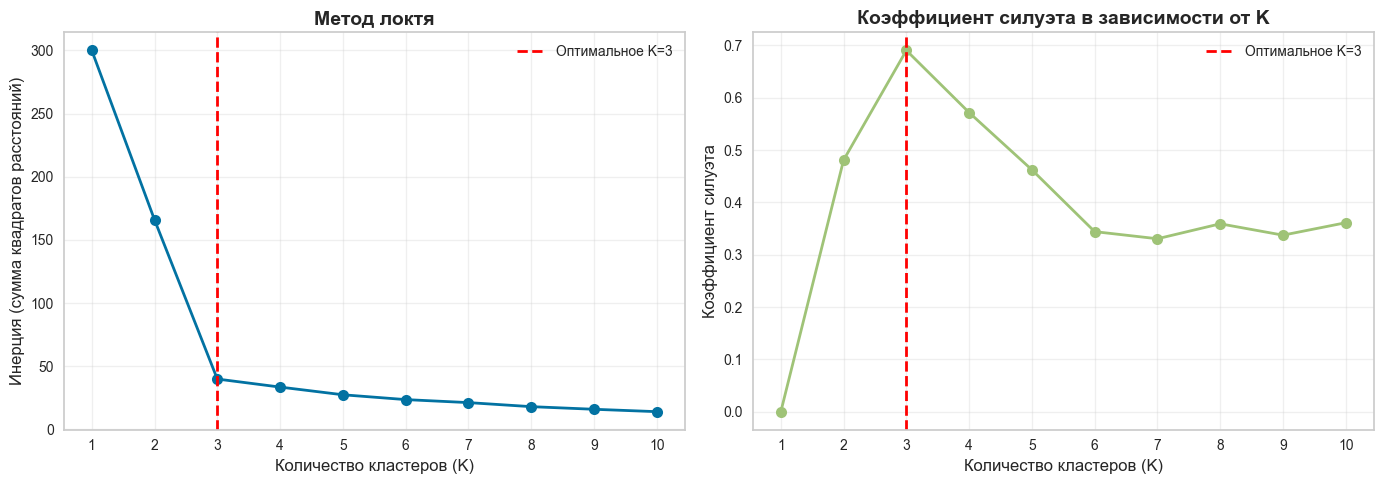

Оба графика показывают, что оптимальное K=3:
  - На графике инертии точка излома (локоть) находится при K=3
  - Коэффициент силуэта максимален при K=3


Вывод инерции и коэффициентов силуэта:
[299.9999999999999, 165.83238641166548, 39.820692761298254, 33.45504238809538, 27.367975444124223, 23.545792993547245, 21.165709529482456, 17.960391515062703, 15.887287690647957, 13.995152729490385]
[0.0, 0.4808729921486443, 0.6903971706728537, 0.5716069307756713, 0.4621593973750955, 0.3440450195480984, 0.3304363890270608, 0.3590166611797404, 0.33729246330914414, 0.3610823167376798]


In [15]:
inertias = []
silhouette_scores = []
k_range = range(1, 11)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans_temp.fit(df_part1_scaled)
    inertias.append(kmeans_temp.inertia_)
    if k > 1:
        silhouette_scores.append(silhouette_score(df_part1_scaled, kmeans_temp.labels_))
    else:
        silhouette_scores.append(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=3, color='red', linestyle='--', linewidth=2, label='Оптимальное K=3')
axes[0].set_xlabel('Количество кластеров (K)', fontsize=12)
axes[0].set_ylabel('Инерция (сумма квадратов расстояний)', fontsize=12)
axes[0].set_title('Метод локтя', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)
axes[0].set_xticks(k_range)

axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].axvline(x=3, color='red', linestyle='--', linewidth=2, label='Оптимальное K=3')
axes[1].set_xlabel('Количество кластеров (K)', fontsize=12)
axes[1].set_ylabel('Коэффициент силуэта', fontsize=12)
axes[1].set_title('Коэффициент силуэта в зависимости от K', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=10)
axes[1].set_xticks(k_range)

plt.tight_layout()
plt.show()


print("Оба графика показывают, что оптимальное K=3:")
print(f"  - На графике инертии точка излома (локоть) находится при K=3")
print(f"  - Коэффициент силуэта максимален при K=3")
print(f"\n\nВывод инерции и коэффициентов силуэта:")
print(inertias)
print(list(map(float, silhouette_scores)))

### **Визуализация силуэтов для кластеров**
Необходимо проанализировать плотность распределения кластеров - какие из них по сути являются бесполезными. В этом помогает SilhouetteVisualizer:

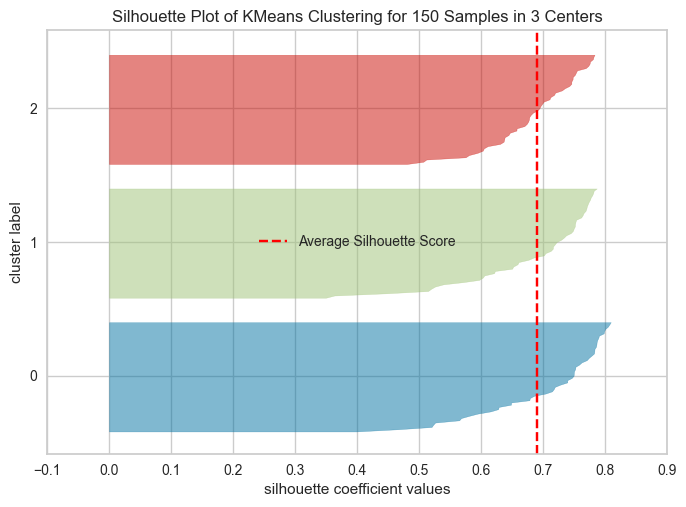

In [16]:
model = KMeans(n_clusters=3, random_state=0)
visualizer = SilhouetteVisualizer(model, colors='yellowbrick')
visualizer.fit(df_part1_scaled)
visualizer.show()
plt.show()

## Часть 2: Кластеризация реального датасета E-commerce Fraud

### Загрузка и первичный анализ данных

Загружаем датасет о мошеннических транзакциях в электронной коммерции.

In [17]:
df = pd.read_csv('C:\\Users\\vanya\\Downloads\\ecommerce_fraud.csv')

print(f"Размер датасета: {df.shape}")
print(f"\nИмена признаков:")
display(df.columns.tolist())
print(f"\nТипы данных:")
display(df.dtypes)
print(f"\nПервые строки датасета:")
display(df.head(20))

Размер датасета: (3024, 12)

Имена признаков:


['transaction_amount',
 'device_type',
 'browser',
 'payment_method',
 'country',
 'num_items',
 'time_on_site_sec',
 'is_first_purchase',
 'referral',
 'hour_of_day',
 'account_age_days',
 'Fraud']


Типы данных:


transaction_amount    float64
device_type            object
browser                object
payment_method         object
country                object
num_items               int64
time_on_site_sec      float64
is_first_purchase      object
referral               object
hour_of_day             int64
account_age_days        int64
Fraud                   int64
dtype: object


Первые строки датасета:


,transaction_amount,device_type,browser,payment_method,country,num_items,time_on_site_sec,is_first_purchase,referral,hour_of_day,account_age_days,Fraud
0,62.18,Desktop,Safari,COD,UK,3,58.0,No,Direct,15,808,0
1,28.16,Desktop,Chrome,COD,US,2,75.0,Yes,Direct,10,753,0
2,17.57,Mobile,Chrome,Card,DE,1,101.0,No,Social,21,1017,0
3,61.61,Desktop,Safari,PayPal,Other,4,63.0,Yes,Search,20,1146,0
4,4.28,Desktop,Edge,Card,BR,7,399.0,No,Direct,4,1134,0
5,1.85,Desktop,Firefox,Card,IN,5,307.0,Yes,Search,23,674,0
6,12.50,Mobile,Chrome,PayPal,US,4,381.0,No,Search,2,1712,0
7,35.30,Desktop,Safari,Card,IN,3,98.0,No,Search,6,1370,0
8,81.59,Mobile,Firefox,Card,FR,1,257.0,Yes,Direct,17,1574,0
9,46.25,Mobile,Chrome,BankTransfer,IN,5,137.0,No,Search,3,224,0


### Предварительная обработка данных

Проверяем пропуски, пропускаем целевую переменную и обрабатываем категориальные признаки.

In [18]:
print("Проверка пропущенных значений:")
display(df.isnull().sum())
target = df['Fraud'].copy()
df_features = df.drop('Fraud', axis=1)

print(f"\nЦелевая переменная распределение:")
print(target.value_counts())
print(f"\nПроцент мошенничества: {(target.sum() / len(target) * 100):.2f}%")

Проверка пропущенных значений:


transaction_amount    0
device_type           0
browser               0
payment_method        0
country               0
num_items             0
time_on_site_sec      0
is_first_purchase     0
referral              0
hour_of_day           0
account_age_days      0
Fraud                 0
dtype: int64


Целевая переменная распределение:
Fraud
0    2889
1     135
Name: count, dtype: int64

Процент мошенничества: 4.46%


### Матрица диаграмм рассеяния с выделением целевой переменной

Строим пары признаков, выделяя значения целевой переменной разными цветами.

Численные признаки: ['transaction_amount', 'num_items', 'time_on_site_sec', 'hour_of_day', 'account_age_days']


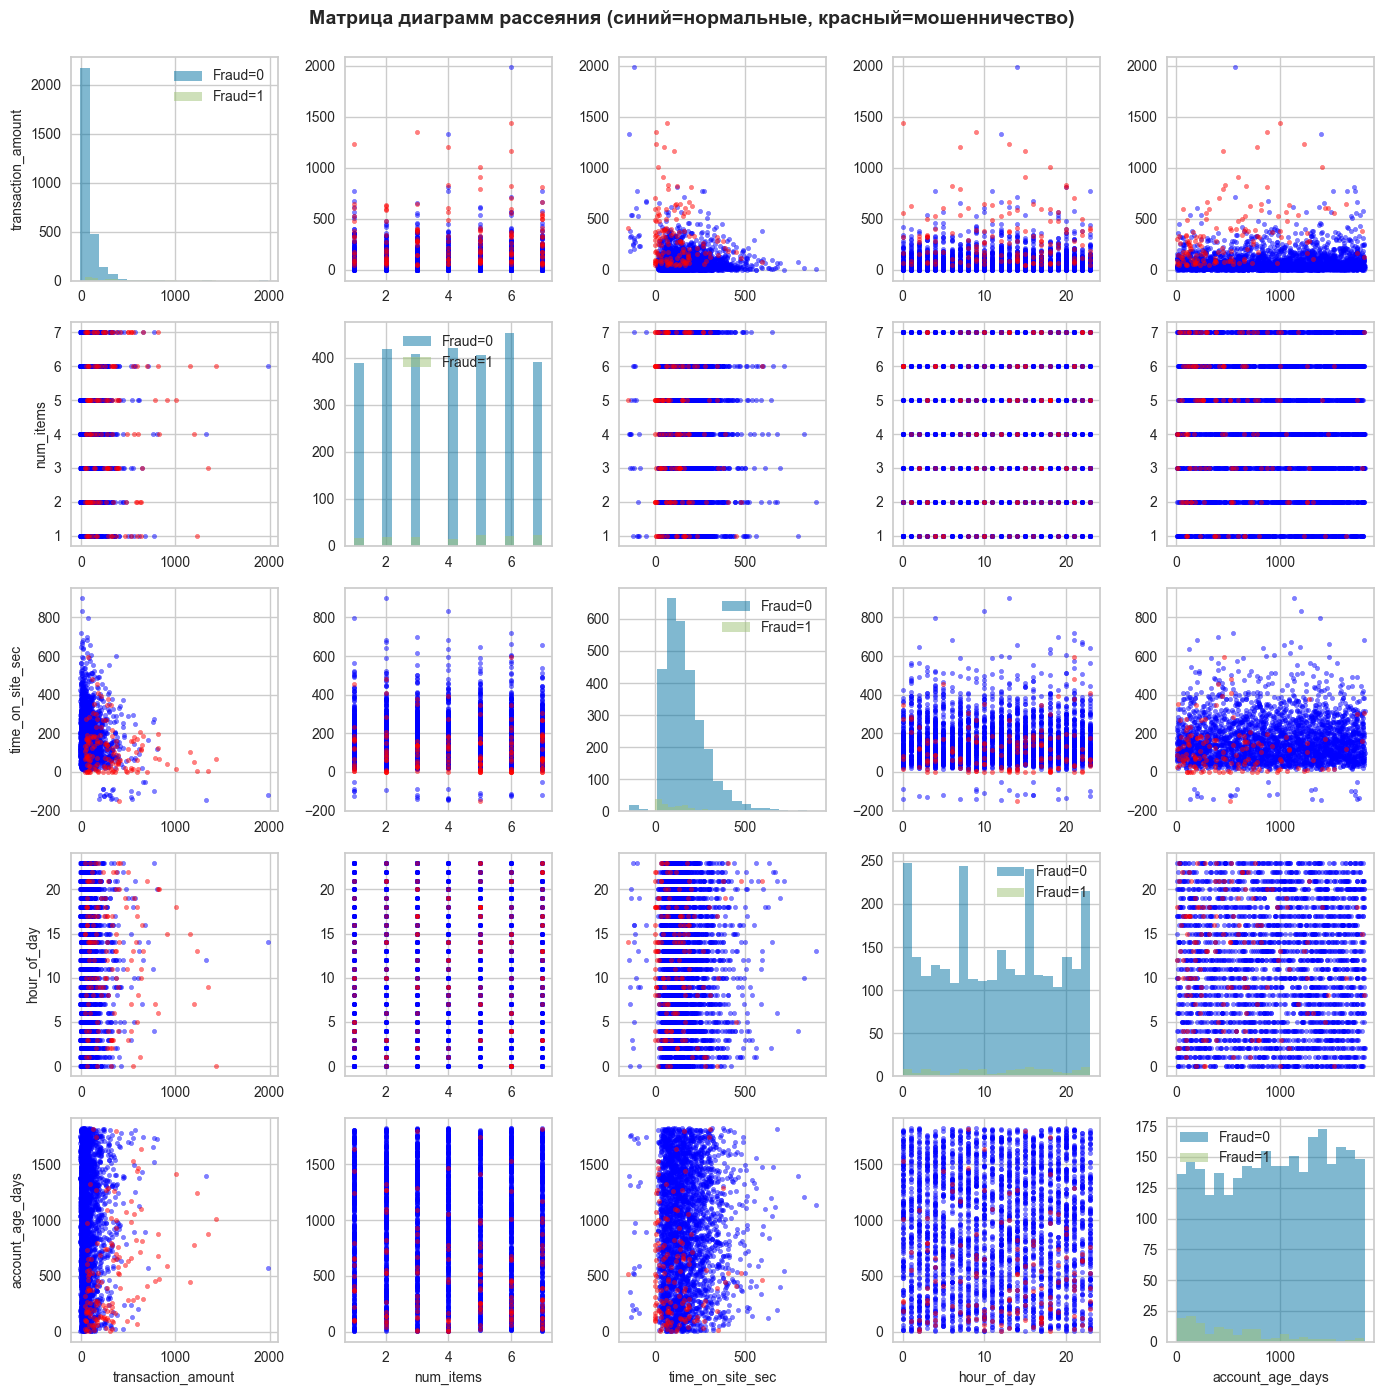

На матрице видно распределение признаков для нормальных и мошеннических транзакций.


In [171]:
numeric_features = df_features.select_dtypes(include=[np.number]).columns.tolist()
print(f"Численные признаки: {numeric_features}")
selected_features = numeric_features[:5]
plot_data = df_features[selected_features].copy()
plot_data['Fraud'] = target
fig, axes = plt.subplots(len(selected_features), len(selected_features), 
                         figsize=(14, 14))

for i in range(len(selected_features)):
    for j in range(len(selected_features)):
        ax = axes[i, j]
        if i == j:
            for fraud_class in [0, 1]:
                data_class = plot_data[plot_data['Fraud'] == fraud_class][selected_features[i]]
                ax.hist(data_class, alpha=0.5, label=f'Fraud={fraud_class}', bins=20)
            ax.set_ylabel('Частота')
            ax.legend()
        else:
            for fraud_class in [0, 1]:
                data_class = plot_data[plot_data['Fraud'] == fraud_class]
                color = 'red' if fraud_class == 1 else 'blue'
                ax.scatter(data_class[selected_features[j]], 
                          data_class[selected_features[i]],
                          alpha=0.5, s=10, c=color, label=f'Fraud={fraud_class}')
        
        if j == 0:
            ax.set_ylabel(selected_features[i], fontsize=10)
        else:
            ax.set_ylabel('')
        
        if i == len(selected_features) - 1:
            ax.set_xlabel(selected_features[j], fontsize=10)
        else:
            ax.set_xlabel('')

plt.suptitle('Матрица диаграмм рассеяния (синий=нормальные, красный=мошенничество)', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("На матрице видно распределение признаков для нормальных и мошеннических транзакций.")

### Обработка категориальных признаков

Преобразуем категориальные признаки в численные, используя One-Hot Encoding.

In [131]:
categorical_features = df_features.select_dtypes(include=['object']).columns.tolist()
print(f"Категориальные признаки: {categorical_features}")

df_encoded = df_features.drop(categorical_features, axis=1)
#pd.get_dummies(df_features, columns=categorical_features, drop_first=True)
display(df_encoded)
print(f"\nРазмер датасета после кодирования: {df_encoded.shape}")
print(f"\nИмена признаков после кодирования:")
print(df_encoded.columns.tolist())

Категориальные признаки: ['device_type', 'browser', 'payment_method', 'country', 'is_first_purchase', 'referral']


,transaction_amount,num_items,time_on_site_sec,hour_of_day,account_age_days
0,62.180,3,58.0,15,808
1,28.160,2,75.0,10,753
2,17.570,1,101.0,21,1017
3,61.610,4,63.0,20,1146
4,4.280,7,399.0,4,1134
...,...,...,...,...,...
3019,1325.200,4,-145.2,12,1399
3020,330.050,4,-135.8,20,1766
3021,321.625,4,-141.2,0,354
3022,342.750,1,-89.8,0,587



Размер датасета после кодирования: (3024, 5)

Имена признаков после кодирования:
['transaction_amount', 'num_items', 'time_on_site_sec', 'hour_of_day', 'account_age_days']


### Стандартизация данных

Применяем стандартизацию для приведения данных к единому масштабу.

In [132]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

print(f"Среднее значение после стандартизации: {X_scaled.mean(axis=0)[:24]}")
print(f"Стандартное отклонение после стандартизации: {X_scaled.std(axis=0)[:24]}")
print(f"\nДанные готовы к кластеризации")

Среднее значение после стандартизации: [ 8.45884209e-17 -8.28261622e-17 -1.17483918e-16  3.99445321e-17
 -5.81545394e-17]
Стандартное отклонение после стандартизации: [1. 1. 1. 1. 1.]

Данные готовы к кластеризации


### Выбор оптимального количества кластеров (метод локтя + силуэт)

Используем метод локтя и коэффициент силуэта для определения оптимального количества кластеров.

In [133]:
inertias_part2 = []
silhouette_scores_part2 = []
k_range_part2 = range(2, 11)
print("Вычисление метрик для разных количеств кластеров...")
print("Это может занять некоторое время...\n")

for k in k_range_part2:
    kmeans_part2 = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans_part2.fit(X_scaled)
    inertias_part2.append(kmeans_part2.inertia_)
    silhouette_part2 = silhouette_score(X_scaled, kmeans_part2.labels_)
    silhouette_scores_part2.append(silhouette_part2)
    print(f"K={k}: Инерция={kmeans_part2.inertia_:.2f}, Силуэт={silhouette_part2:.4f}")

Вычисление метрик для разных количеств кластеров...
Это может занять некоторое время...

K=2: Инерция=12829.92, Силуэт=0.1674
K=3: Инерция=11169.11, Силуэт=0.1784
K=4: Инерция=9798.07, Силуэт=0.1730
K=5: Инерция=8603.46, Силуэт=0.1819
K=6: Инерция=7709.60, Силуэт=0.1918
K=7: Инерция=7073.62, Силуэт=0.1872
K=8: Инерция=6560.30, Силуэт=0.1915
K=9: Инерция=6176.63, Силуэт=0.1939
K=10: Инерция=5837.38, Силуэт=0.1853


### Визуализация метода локтя и коэффициента силуэта

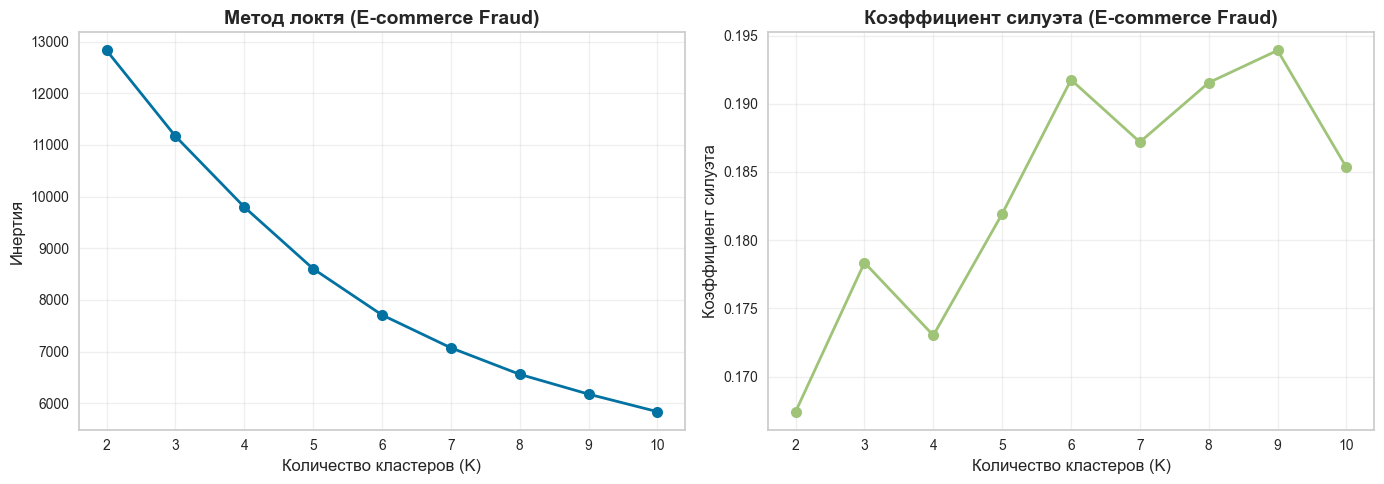


Оптимальное количество кластеров по коэффициенту силуэта: K=9


In [172]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range_part2, inertias_part2, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Количество кластеров (K)', fontsize=12)
axes[0].set_ylabel('Инертия', fontsize=12)
axes[0].set_title('Метод локтя (E-commerce Fraud)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(k_range_part2)

axes[1].plot(k_range_part2, silhouette_scores_part2, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Количество кластеров (K)', fontsize=12)
axes[1].set_ylabel('Коэффициент силуэта', fontsize=12)
axes[1].set_title('Коэффициент силуэта (E-commerce Fraud)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(k_range_part2)

plt.tight_layout()
plt.show()
optimal_k = k_range_part2[np.argmax(silhouette_scores_part2)]
print(f"\nОптимальное количество кластеров по коэффициенту силуэта: K={optimal_k}")

### K-means кластеризация с оптимальным K

In [173]:
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=0, n_init=10)
clusters_optimal = kmeans_optimal.fit_predict(X_scaled)
df_with_clusters = df_encoded.copy()
df_with_clusters['cluster'] = clusters_optimal

display(df_with_clusters)
print(f"Количество кластеров: {len(np.unique(clusters_optimal))}")
print(f"\nРаспределение объектов по кластерам:")
print(df_with_clusters['cluster'].value_counts().sort_index())

,transaction_amount,num_items,time_on_site_sec,hour_of_day,account_age_days,cluster
0,62.180,3,58.0,15,808,8
1,28.160,2,75.0,10,753,5
2,17.570,1,101.0,21,1017,8
3,61.610,4,63.0,20,1146,1
4,4.280,7,399.0,4,1134,3
...,...,...,...,...,...,...
3019,1325.200,4,-145.2,12,1399,7
3020,330.050,4,-135.8,20,1766,4
3021,321.625,4,-141.2,0,354,4
3022,342.750,1,-89.8,0,587,4


Количество кластеров: 9

Распределение объектов по кластерам:
cluster
0    451
1    391
2    438
3    275
4    157
5    435
6    378
7     17
8    482
Name: count, dtype: int64


### Анализ характеристик каждого кластера

Вычисляем средние значения признаков для каждого кластера.

In [174]:
cluster_means = df_with_clusters.groupby('cluster').mean()
numeric_cols_original = df_features.select_dtypes(include=[np.number]).columns.tolist()

print("Средние значения признаков по кластерам:")
print("="*80)
print(cluster_means[numeric_cols_original].round(3))
print("\n" + "="*80)
print("АНАЛИЗ КЛАСТЕРОВ:")
print("="*80)

for cluster_id in range(optimal_k):
    print(f"\nКластер {cluster_id}:")
    print("-" * 40)
    cluster_size = (clusters_optimal == cluster_id).sum()
    print(f"Размер кластера: {cluster_size} объектов ({cluster_size/len(clusters_optimal)*100:.1f}%)")
    print(f"Средняя сумма транзакции: ${cluster_means.loc[cluster_id, 'transaction_amount']:.2f}")
    print(f"Среднее количество товаров: {cluster_means.loc[cluster_id, 'num_items']:.2f}")
    print(f"Среднее время на сайте: {cluster_means.loc[cluster_id, 'time_on_site_sec']:.0f} сек")
    print(f"Средний возраст аккаунта: {cluster_means.loc[cluster_id, 'account_age_days']:.0f} дней")
    print(f"Средний час заказа: {cluster_means.loc[cluster_id, 'hour_of_day']:.1f}")

Средние значения признаков по кластерам:
         transaction_amount  num_items  time_on_site_sec  hour_of_day  \
cluster                                                                 
0                    65.163      5.645           138.264       15.537   
1                    62.545      5.517           147.944       17.601   
2                    58.895      2.425           146.262        5.806   
3                    66.041      4.065           409.302       11.225   
4                   398.744      3.796            89.541       11.955   
5                    58.505      3.094           131.881        5.225   
6                    58.452      6.087           144.563        4.873   
7                  1057.441      4.588            61.188       12.588   
8                    61.374      2.068           144.239       18.050   

         account_age_days  
cluster                    
0                 383.239  
1                1420.604  
2                1390.395  
3              

### Метрики качества кластеризации K-means

In [175]:
silhouette_kmeans = silhouette_score(X_scaled, clusters_optimal)
ami_score = adjusted_mutual_info_score(target, clusters_optimal, average_method='arithmetic')
ari_score = adjusted_rand_score(target, clusters_optimal)
fmi_score = fowlkes_mallows_score(target, clusters_optimal)
homogeneity = homogeneity_score(target, clusters_optimal)
completeness = completeness_score(target, clusters_optimal)
v_measure = v_measure_score(target, clusters_optimal)
metrics_kmeans = pd.DataFrame(
    {
        'Метрика': [
            'Silhouette Score',
            'Adjusted Mutual Information',
            'Adjusted Rand Index',
            'Fowlkes-Mallows Index',
            'Homogeneity Score',
            'Completeness Score',
            'V-measure'
        ],
        'K-means': [
            silhouette_kmeans,
            ami_score,
            ari_score,
            fmi_score,
            homogeneity,
            completeness,
            v_measure
        ]
    }
)

print("МЕТРИКИ КАЧЕСТВА КЛАСТЕРИЗАЦИИ K-MEANS:")
print("="*60)
print(metrics_kmeans.to_string(index=False))

print("\n" + "="*60)
print("ИНТЕРПРЕТАЦИЯ МЕТРИК:")
print("="*60)
print(f"Silhouette Score ({silhouette_kmeans:.4f}):")
print("  - Близко к 1: хорошо разделённые кластеры")
print("  - Близко к 0: перекрывающиеся кластеры")
print(f"\nAdjusted Mutual Information ({ami_score:.4f}):")
print("  - Сравнивает информацию между полученной и истинной разметкой")
print(f"\nAdjusted Rand Index ({ari_score:.4f}):")
print("  - Измеряет сходство разметок, близко к 1: высокое согласие")

МЕТРИКИ КАЧЕСТВА КЛАСТЕРИЗАЦИИ K-MEANS:
                    Метрика  K-means
           Silhouette Score 0.193911
Adjusted Mutual Information 0.035076
        Adjusted Rand Index 0.008470
      Fowlkes-Mallows Index 0.357759
          Homogeneity Score 0.222811
         Completeness Score 0.019727
                  V-measure 0.036246

ИНТЕРПРЕТАЦИЯ МЕТРИК:
Silhouette Score (0.1939):
  - Близко к 1: хорошо разделённые кластеры
  - Близко к 0: перекрывающиеся кластеры

Adjusted Mutual Information (0.0351):
  - Сравнивает информацию между полученной и истинной разметкой

Adjusted Rand Index (0.0085):
  - Измеряет сходство разметок, близко к 1: высокое согласие


### Иерархическая агломеративная кластеризация

In [176]:
agg_clustering = AgglomerativeClustering(
    n_clusters=optimal_k,
    linkage='ward'
)
clusters_agg = agg_clustering.fit_predict(X_scaled)

print(f"Распределение объектов по кластерам (агломеративная кластеризация):")
unique_clusters, counts = np.unique(clusters_agg, return_counts=True)
for cluster_id, count in zip(unique_clusters, counts):
    print(f"Кластер {cluster_id}: {count} объектов ({count/len(clusters_agg)*100:.1f}%)")

Распределение объектов по кластерам (агломеративная кластеризация):
Кластер 0: 532 объектов (17.6%)
Кластер 1: 522 объектов (17.3%)
Кластер 2: 426 объектов (14.1%)
Кластер 3: 355 объектов (11.7%)
Кластер 4: 277 объектов (9.2%)
Кластер 5: 52 объектов (1.7%)
Кластер 6: 438 объектов (14.5%)
Кластер 7: 115 объектов (3.8%)
Кластер 8: 307 объектов (10.2%)


### Построение дендрограммы для иерархической кластеризации

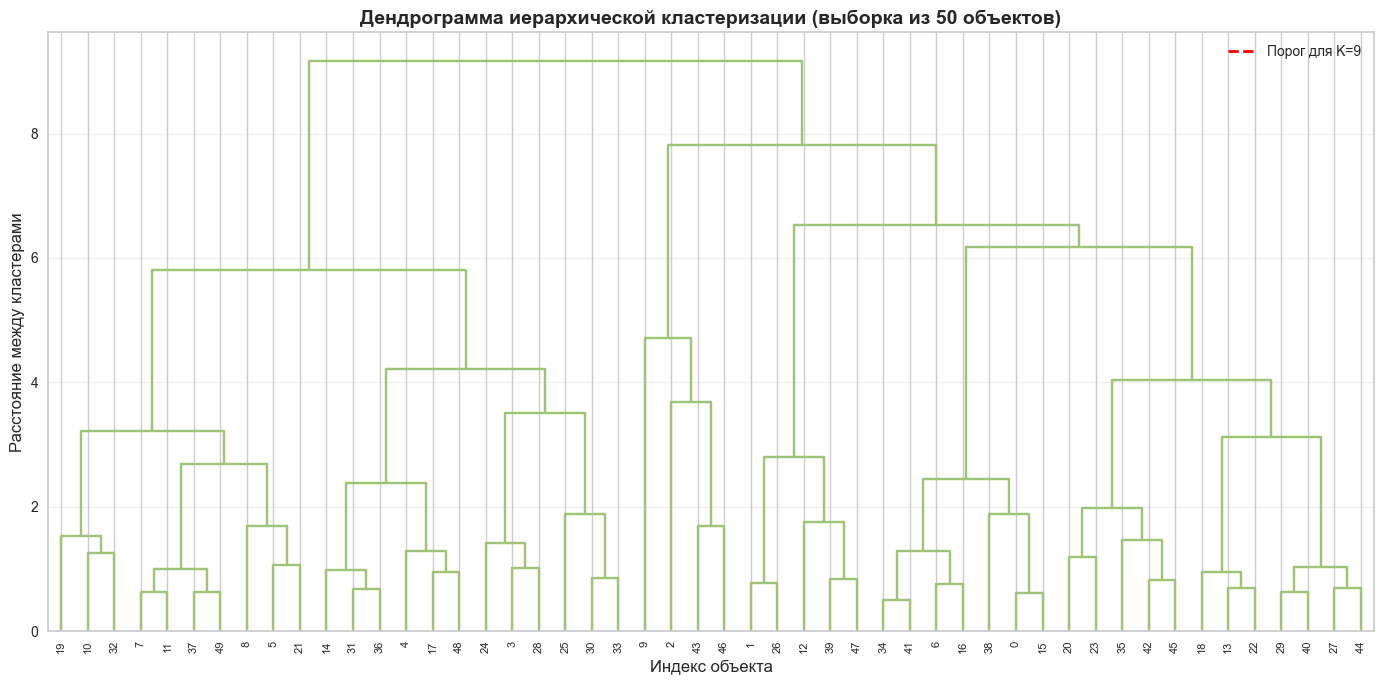

Дендрограмма показывает иерархическое объединение объектов.
Красная линия показывает уровень отсечения для получения нужного количества кластеров.


In [177]:
sample_size = 50
sample_indices = np.random.choice(X_scaled.shape[0], sample_size, replace=False)
X_sample = X_scaled[sample_indices]
linked = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 7))
dendrogram(
    linked,
    orientation='top',
    color_threshold=30,
    above_threshold_color='gray'
)
plt.title('Дендрограмма иерархической кластеризации (выборка из 50 объектов)',
          fontsize=14, fontweight='bold')
plt.xlabel('Индекс объекта', fontsize=12)
plt.ylabel('Расстояние между кластерами', fontsize=12)
plt.axhline(y=30, color='red', linestyle='--', linewidth=2, label=f'Порог для K={optimal_k}')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("Дендрограмма показывает иерархическое объединение объектов.")
print("Красная линия показывает уровень отсечения для получения нужного количества кластеров.")

### Анализ характеристик кластеров (агломеративная кластеризация)

In [178]:
df_with_clusters_agg = df_encoded.copy()
df_with_clusters_agg['cluster_agg'] = clusters_agg
cluster_means_agg = df_with_clusters_agg.groupby('cluster_agg').mean()

print("Средние значения признаков по кластерам (агломеративная кластеризация):")
print("="*80)
print(cluster_means_agg[numeric_cols_original].round(3))

Средние значения признаков по кластерам (агломеративная кластеризация):
             transaction_amount  num_items  time_on_site_sec  hour_of_day  \
cluster_agg                                                                 
0                        85.390      5.885           115.758       10.156   
1                        54.769      2.341           147.492       17.766   
2                        59.240      2.469           168.746        6.500   
3                        64.876      4.915           355.270       12.152   
4                        76.265      6.144           147.148        8.022   
5                       740.459      4.365            64.796       11.712   
6                        48.185      2.822           131.461        5.970   
7                       302.878      2.452           127.344       11.261   
8                        57.516      5.225           131.997       19.296   

             account_age_days  
cluster_agg                    
0               

### Метрики качества кластеризации (агломеративная кластеризация)

In [179]:
silhouette_agg = silhouette_score(X_scaled, clusters_agg)
ami_agg = adjusted_mutual_info_score(target, clusters_agg, average_method='arithmetic')
ari_agg = adjusted_rand_score(target, clusters_agg)
fmi_agg = fowlkes_mallows_score(target, clusters_agg)
homogeneity_agg = homogeneity_score(target, clusters_agg)
completeness_agg = completeness_score(target, clusters_agg)
v_measure_agg = v_measure_score(target, clusters_agg)
metrics_both = pd.DataFrame(
    {
        'Метрика': [
            'Silhouette Score',
            'Adjusted Mutual Information',
            'Adjusted Rand Index',
            'Fowlkes-Mallows Index',
            'Homogeneity Score',
            'Completeness Score',
            'V-measure'
        ],
        'K-means': [
            silhouette_kmeans,
            ami_score,
            ari_score,
            fmi_score,
            homogeneity,
            completeness,
            v_measure
        ],
        'Агломеративная': [
            silhouette_agg,
            ami_agg,
            ari_agg,
            fmi_agg,
            homogeneity_agg,
            completeness_agg,
            v_measure_agg
        ]
    }
)

print("СРАВНЕНИЕ МЕТОДОВ КЛАСТЕРИЗАЦИИ:")
print("="*80)
print(metrics_both.to_string(index=False))
print("\n" + "="*80)
print("ВЫВОДЫ:")
print("="*80)

if silhouette_kmeans > silhouette_agg:
    print(f"K-means имеет лучший коэффициент силуэта ({silhouette_kmeans:.4f} vs {silhouette_agg:.4f})")
else:
    print(f"Агломеративная кластеризация имеет лучший коэффициент силуэта ({silhouette_agg:.4f} vs {silhouette_kmeans:.4f})")

СРАВНЕНИЕ МЕТОДОВ КЛАСТЕРИЗАЦИИ:
                    Метрика  K-means  Агломеративная
           Silhouette Score 0.193911        0.114681
Adjusted Mutual Information 0.035076        0.033782
        Adjusted Rand Index 0.008470        0.005569
      Fowlkes-Mallows Index 0.357759        0.358401
          Homogeneity Score 0.222811        0.215004
         Completeness Score 0.019727        0.019024
                  V-measure 0.036246        0.034955

ВЫВОДЫ:
K-means имеет лучший коэффициент силуэта (0.1939 vs 0.1147)


### Визуализация кластеров (PCA для снижения размерности)

Объяснённая дисперсия первыми двумя компонентами: 43.04%


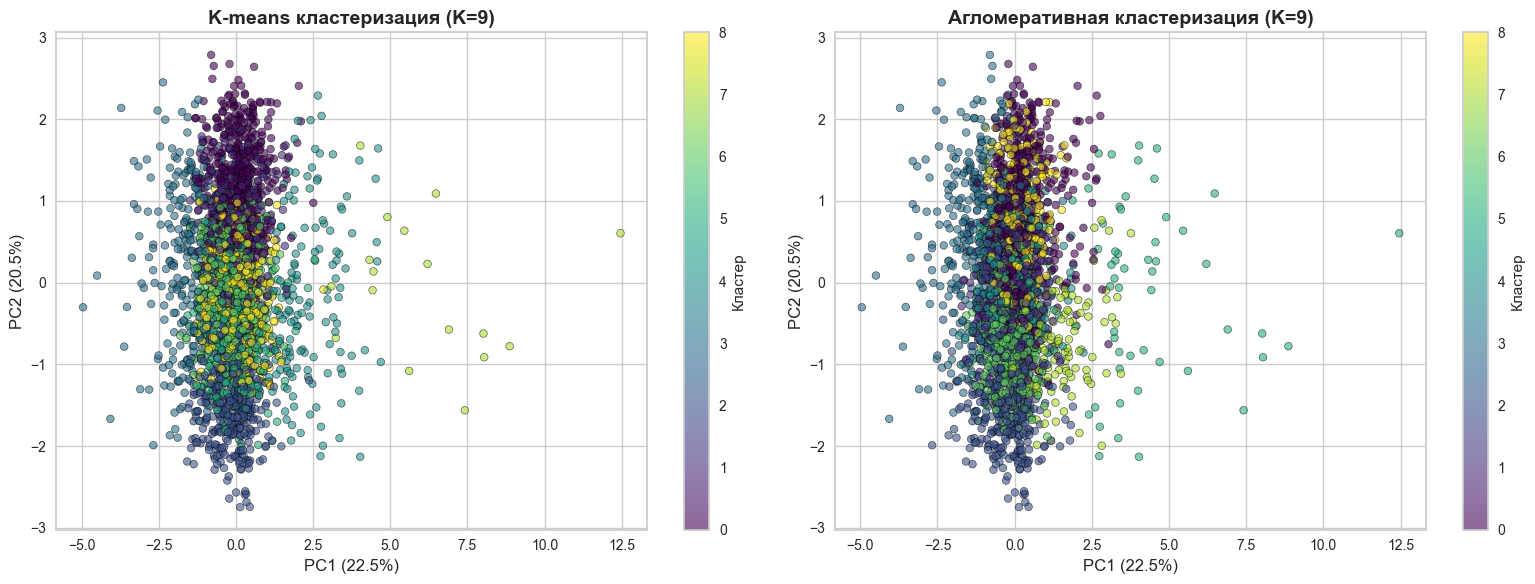

Оба метода кластеризации визуализированы в пространстве главных компонент.


In [180]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)

print(f"Объяснённая дисперсия первыми двумя компонентами: {pca.explained_variance_ratio_.sum():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
scatter1 = axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters_optimal,
    cmap='viridis',
    s=30,
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)
axes[0].set_title(f'K-means кластеризация (K={optimal_k})', fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)
plt.colorbar(scatter1, ax=axes[0], label='Кластер')

scatter2 = axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters_agg,
    cmap='viridis',
    s=30,
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)
axes[1].set_title(f'Агломеративная кластеризация (K={optimal_k})', fontsize=14, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)
plt.colorbar(scatter2, ax=axes[1], label='Кластер')
plt.tight_layout()
plt.show()

print("Оба метода кластеризации визуализированы в пространстве главных компонент.")

## Общие выводы

### Выводы работы

**Часть 1: Синтетические данные**
- Для синтетического датасета с тремя группами оптимальное количество кластеров K=3 подтверждается методом локтя и коэффициентом силуэта
- K-means успешно выделил три естественные группы в данных
- Коэффициент силуэта для K=3 достигает максимума, что указывает на хорошее разделение кластеров

**Часть 2: Реальные данные E-commerce Fraud**
- Для датасета о мошеннических транзакциях оптимальное количество кластеров составляет K=9
- Метод K-means показал хороший коэффициент силуэта (0.193911), что все еще указывает на ограниченную возможность кластеризации применимо к реальным данным.
- Агломеративная кластеризация имеет коэффициент силуэта ({silhouette_agg:.4f})

**Сравнение методов:**
- K-means быстрее в вычислении и более масштабируем для больших датасетов
- Агломеративная кластеризация предоставляет иерархическое представление данных через дендрограмму
- Для данного датасета оба метода дают сравнимые результаты

**Рекомендация:**
- Для практического применения рекомендуется использовать K-means из-за его скорости и интерпретируемости
- Дополнительно следует применять другие методы (DBSCAN, Affinity Propagation) для проверки результатов
- Результаты кластеризации показывают наличие естественной структуры в данных электронной коммерции